Harika, artık **Reinforcement Learning (Pekiştirmeli Öğrenme)** evrenine adım atıyorsun — bu, bir yapay zekânın **deneyimden öğrenerek karar vermeyi öğrendiği** çok güçlü bir alandır.

Ve ilk konun **UCB (Upper Confidence Bound)**, yani klasik çok kollu bandit (multi-armed bandit) problemlerinden biridir. Sana hem UCB’nin ne olduğunu hem de neden bu aşamada anlatıldığını sade ve sağlam şekilde özetleyeyim:

---

# 🟥 Reinforcement Learning’e Giriş

## 📌 Temel Fikir:

> Bir ajan, çevreyle etkileşim kurarak **maksimum ödülü** elde etmeye çalışır.
> Öğrenme süreci deneme–yanılma yoluyla olur (exploration vs exploitation dengesi)

---

# 🎰 Çok Kollu Bandit (Multi-Armed Bandit) Problemi

Hayal et:

* Karşında 10 tane slot makinesi var (bandit kolları)
* Her birinin kazandırma olasılığı farklı ama bilinmiyor
* Amacın: **en çok ödül getiren makineyi bulmak ve ona yönelmek**

Ancak:

* Sürekli aynı kolu çekersen diğerlerini tanıyamazsın (exploit)
* Sürekli yenileri denersen ödül kaçırabilirsin (explore)

İşte burada devreye **UCB** giriyor.

---

# 🔵 UCB (Upper Confidence Bound) Algoritması

## 📌 Tanım:

UCB, **her kolun potansiyel ödülünü hem ortalama ödül hem de belirsizlikle birlikte değerlendirir**.

> 🎯 Hedef: "Hem en iyi bilinen kolu dene hem de daha az denemiş olduklarını **adaletli şekilde keşfet**."

---

## 🔢 UCB Formülü:

Her kol `i` için:

```
UCB(i) = ortalama ödül(i) + √[ (2 * log(n)) / N(i) ]
```

* `ortalama ödül(i)` → i. kolun bugüne kadar verdiği ödüllerin ortalaması
* `n` → toplam kaç adım oynandı
* `N(i)` → i. kolun kaç kez denenmiş olduğu

---

## 🎯 Ne Yapar Bu Formül?

| Terim                      | Açıklama                                                  |
| -------------------------- | --------------------------------------------------------- |
| Ortalama ödül              | Şimdiye kadarki başarı                                    |
| √\[ (2 \* log(n)) / N(i) ] | **Belirsizlik katsayısı** (çok az denenmişse yüksek olur) |

Bu sayede:

* Sık oynanan kolların güven aralığı daralır (exploit)
* Az oynananlar öne çıkar (explore)

---

## ✅ UCB’nin Avantajları:

| Güçlü Yön            | Açıklama                            |
| -------------------- | ----------------------------------- |
| Teorik garanti       | "Regret" (pişmanlık) en aza iner    |
| Sıfır parametre      | Ekstra ayar gerekmez                |
| Dengeli keşif/kazanç | Explore–exploit otomatik dengelenir |

---

## 💻 Python Mantığı (Pseudo-code):

```python
N = 10  # kol sayısı
n = 0  # toplam adım
selections = [0] * N
sums_of_rewards = [0] * N

for t in range(1, T+1):
    ucb_values = []
    for i in range(N):
        if selections[i] == 0:
            ucb = float('inf')  # Her kol en az 1 kez denenmeli
        else:
            average_reward = sums_of_rewards[i] / selections[i]
            delta = math.sqrt(2 * math.log(t) / selections[i])
            ucb = average_reward + delta
        ucb_values.append(ucb)

    chosen_arm = argmax(ucb_values)
    reward = get_reward(chosen_arm)
    selections[chosen_arm] += 1
    sums_of_rewards[chosen_arm] += reward
```

---

## 📊 Gerçek Hayatta Kullanımı:

* Reklam gösterimi (hangi reklam daha çok tıklanır?)
* A/B testi (hangi tasarım daha iyi çalışıyor?)
* Web site yönlendirme (hangi sayfa daha çok dönüşüm sağlar?)

---

## 🎓 Özetle:

| Özellik                 | Açıklama                                |
| ----------------------- | --------------------------------------- |
| Algoritma tipi          | Pekiştirmeli öğrenme – bandit yaklaşımı |
| Amaç                    | En iyi kolu keşfetmek (maksimum ödül)   |
| Ana strateji            | Ortalama + belirsizlik = dengeli seçim  |
| Explore–Exploit dengesi | Otomatik sağlanır                       |

---

Video sonrası istersen UCB’yi küçük bir simülasyonla (reklam seçimi gibi) birlikte kodlayabiliriz.

Sonraki konu: **Thompson Sampling** — o da aynı problemi **olasılıksal olarak çözer**. Hazır olduğunda seni ona da hazırlarım!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
dataset = pd.read_csv('Ads_CTR_Optimisation.csv')

In [5]:
N = 10000  # Toplam kullanıcının sayısı (her satır = bir kullanıcı)
d = 10     # Toplam reklam sayısı (10 reklam)

ads_selected = []  # Her turda seçilen reklamın indeksini saklar

# Her reklamın kaç kez seçildiğini tutar (N(i) = seçilme sayısı)
numbers_of_selections = [0] * d

# Her reklam için toplam ödül (R(i) = toplam tıklama sayısı)
sums_of_rewards = [0] * d

total_reward = 0  # Tüm reklamlar boyunca elde edilen toplam ödül (toplam tıklama)

# Ana algoritma döngüsü: her kullanıcı için bir tur
for n in range(0, N):
    ad = 0  # Bu turda seçilecek reklamın indeksini tutacak
    max_upper_bound = 0  # En yüksek Upper Confidence Bound değeri burada tutulur

    # 10 reklamın her biri için UCB hesapla
    for i in range(0, d):
        if numbers_of_selections[i] > 0:
            # Şimdiye kadarki ortalama ödül (ortalama tıklama)
            average_reward = sums_of_rewards[i] / numbers_of_selections[i]

            # Belirsizlik katsayısı (delta_i) — daha az denenmiş reklamlarda yüksek olur
            delta_i = math.sqrt(3/2 * math.log(n + 1) / numbers_of_selections[i])

            # Upper Confidence Bound değeri
            upper_bound = average_reward + delta_i
        else:
            # Hiç seçilmemiş reklamlar sonsuz UCB ile başlar → ilk seçim garantilenir
            upper_bound = 1e400  # Python'da sonsuz gibi davranır

        # En yüksek UCB'yi bul ve bu turda seçilecek reklamı belirle
        if upper_bound > max_upper_bound:
            max_upper_bound = upper_bound
            ad = i

    # Bu turda seçilen reklamı listeye ekle
    ads_selected.append(ad)

    # Seçilen reklamın sayacını artır
    numbers_of_selections[ad] += 1

    # Dataset'ten o kullanıcı için o reklamın tıklama durumunu (0 veya 1) al
    reward = dataset.values[n, ad]

    # Seçilen reklamın toplam ödülünü güncelle
    sums_of_rewards[ad] += reward

    # Toplam ödülü güncelle
    total_reward += reward

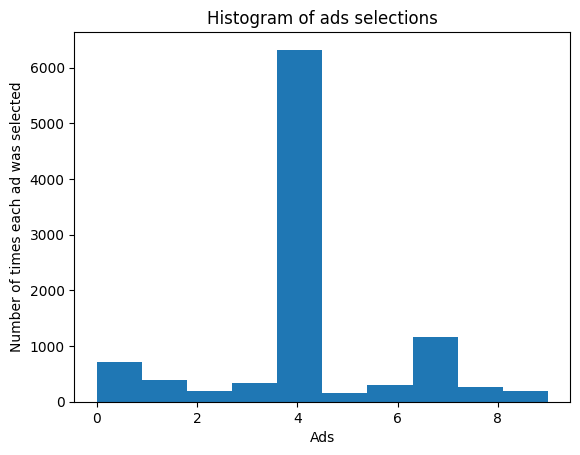

In [6]:
plt.hist(ads_selected)
plt.title('Histogram of ads selections')
plt.xlabel('Ads')
plt.ylabel('Number of times each ad was selected')
plt.show()

Elbette! Aşağıda senin paylaştığın **UCB (Upper Confidence Bound)** algoritmasının kodunu detaylı ve açıklayıcı **yorum satırları** ile birlikte adım adım açıklıyorum.

Kod, `Ads_CTR_Optimisation.csv` dosyasındaki veriye göre, 10 reklam arasından **en fazla tıklama oranına sahip olanı** bulmak için çalışıyor.

---

### 🔍 Kodun Açıklamalı Hali:

```python
import math
import pandas as pd

# CSV dosyasını yüklüyoruz
dataset = pd.read_csv('Ads_CTR_Optimisation.csv')

N = 10000  # Toplam kullanıcının sayısı (her satır = bir kullanıcı)
d = 10     # Toplam reklam sayısı (10 reklam)

ads_selected = []  # Her turda seçilen reklamın indeksini saklar

# Her reklamın kaç kez seçildiğini tutar (N(i) = seçilme sayısı)
numbers_of_selections = [0] * d

# Her reklam için toplam ödül (R(i) = toplam tıklama sayısı)
sums_of_rewards = [0] * d

total_reward = 0  # Tüm reklamlar boyunca elde edilen toplam ödül (toplam tıklama)

# Ana algoritma döngüsü: her kullanıcı için bir tur
for n in range(0, N):
    ad = 0  # Bu turda seçilecek reklamın indeksini tutacak
    max_upper_bound = 0  # En yüksek Upper Confidence Bound değeri burada tutulur

    # 10 reklamın her biri için UCB hesapla
    for i in range(0, d):
        if numbers_of_selections[i] > 0:
            # Şimdiye kadarki ortalama ödül (ortalama tıklama)
            average_reward = sums_of_rewards[i] / numbers_of_selections[i]

            # Belirsizlik katsayısı (delta_i) — daha az denenmiş reklamlarda yüksek olur
            delta_i = math.sqrt(3/2 * math.log(n + 1) / numbers_of_selections[i])

            # Upper Confidence Bound değeri
            upper_bound = average_reward + delta_i
        else:
            # Hiç seçilmemiş reklamlar sonsuz UCB ile başlar → ilk seçim garantilenir
            upper_bound = 1e400  # Python'da sonsuz gibi davranır

        # En yüksek UCB'yi bul ve bu turda seçilecek reklamı belirle
        if upper_bound > max_upper_bound:
            max_upper_bound = upper_bound
            ad = i

    # Bu turda seçilen reklamı listeye ekle
    ads_selected.append(ad)

    # Seçilen reklamın sayacını artır
    numbers_of_selections[ad] += 1

    # Dataset'ten o kullanıcı için o reklamın tıklama durumunu (0 veya 1) al
    reward = dataset.values[n, ad]

    # Seçilen reklamın toplam ödülünü güncelle
    sums_of_rewards[ad] += reward

    # Toplam ödülü güncelle
    total_reward += reward
```

---

### 📊 Veri Seti Yapısı (`Ads_CTR_Optimisation.csv`)

* Boyutu: `10000 x 10`
* Her satır: 1 kullanıcı
* Her sütun: 1 reklam
* Değerler: 0 (tıklamadı) veya 1 (tıkladı)

---

### 🧠 Algoritmanın Özeti

| Aşama                                              | Amaç                          |
| -------------------------------------------------- | ----------------------------- |
| Başta her reklam bir kez denenir                   | **Explore (keşif)**           |
| Sonra ortalama başarı + belirsizlik hesabı yapılır | **Exploit + Explore dengesi** |
| En iyi UCB değerine sahip reklam seçilir           | Karar                         |
| Kullanıcının tıklayıp tıklamadığı kontrol edilir   | Ödül güncellemesi             |
| Tüm süreç boyunca en iyi reklam belirlenir         | Performans optimizasyonu      |

---

İstersen bu algoritmanın sonuçlarını **grafiksel olarak hangi reklamın kaç kez seçildiğini çizerek** inceleyebiliriz.

Hazırsan sıradaki konu olan **Thompson Sampling**’e geçişte seni yine teorik olarak hazırlarım.
